In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create the synthetic dataset with the issues you mentioned
data = {
    'timestamp': pd.to_datetime(['2023-10-26 10:00:00', '2023-10-26 10:01:00', '2023-10-26 10:02:00', '2023-10-26 10:03:00', '2023-10-26 10:04:00', '2023-10-26 10:05:00', '2023-10-26 10:06:00', '2023-10-26 10:07:00', '2023-10-26 10:08:00', '2023-10-26 10:09:00']),
    'source_ip': ['192.168.1.10', '192.168.1.11', '192.168.1.10', '10.0.0.5', '192.168.1.12', '192.168.1.10', '192.168.1.11', '10.0.0.5', '192.168.1.13', '192.168.1.10'],
    'destination_ip': ['8.8.8.8', '8.8.4.4', '8.8.8.8', '192.168.1.100', '8.8.8.8', '8.8.4.4', '8.8.8.8', '192.168.1.100', '8.8.8.8', '8.8.4.4'],
    'source_port': [54321, 12345, 54321, 60000, 54322, 12345, 54321, 60000, 54323, 12345],
    'destination_port': [53, 53, 53, 80, 53, 53, 53, 80, 53, 53],
    'protocol': ['UDP', 'UDP', 'UDP', 'TCP', 'UDP', 'UDP', 'UDP', 'TCP', 'UDP', 'UDP'],
    'duration_sec': [120, 150, np.nan, 300, 130, 160, 125, np.nan, 140, 155],
    'bytes_sent': [1024, 1536, 1024, 5120, 1100, 1600, 1050, 5200, 1150, 1580],
    'bytes_received': [512, 768, 512, 2560, 550, 800, 525, 2600, 575, 790],
    'alert_type': ['None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None', 'None'],
    'malicious_flag': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
}
df = pd.DataFrame(data)

# Inject the "dirty" data
# First, convert bytes_sent to object type so it can handle the string we're about to add
df['bytes_sent'] = df['bytes_sent'].astype(object)

df.loc[2, 'source_ip'] = np.nan
df.loc[4, 'bytes_sent'] = '1100 bytes' # This will work now without the warning
df.loc[7, 'duration_sec'] = 99999 

# Add the duplicate row
df = pd.concat([df, df.iloc[[0]]], ignore_index=True)

print(f"Initial Shape: {df.shape}")

Initial Shape: (11, 11)


In [3]:
# Fix data types
df['bytes_sent'] = df['bytes_sent'].apply(lambda x: int(str(x).replace(' bytes', '').strip()))
df['protocol'] = df['protocol'].astype('category')

# Impute missing values
df['source_ip'].fillna(df['source_ip'].mode()[0], inplace=True)
df['duration_sec'].fillna(df['duration_sec'].median(), inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

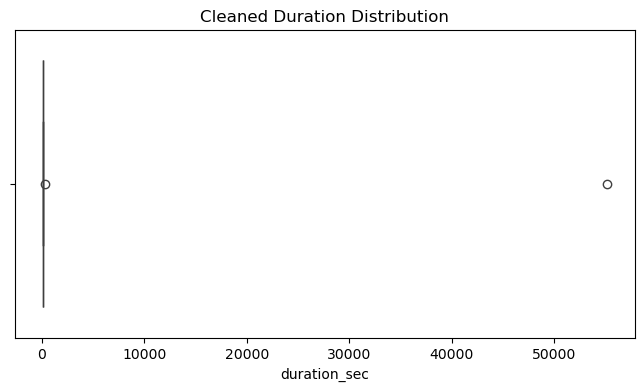

In [4]:
p95 = df['duration_sec'].quantile(0.95)
df['duration_sec'] = np.where(df['duration_sec'] > p95, p95, df['duration_sec'])

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['duration_sec'])
plt.title('Cleaned Duration Distribution')
plt.show()

In [5]:
# 1. Severity Mode
df_sev_mode = alert_df['severity'].mode()[0]
alert_df['severity'].fillna(df_sev_mode, inplace=True)

# 2. Source IP Mode
df_ip_mode = alert_df['source_ip'].mode()[0]
alert_df['source_ip'].fillna(df_ip_mode, inplace=True)

# 3. Event Count Median
df_count_median = alert_df['event_count'].median()
alert_df['event_count'].fillna(df_count_median, inplace=True)

print(alert_df.isnull().sum())

NameError: name 'alert_df' is not defined

In [6]:
# Initialize the Exercise 1 data
alert_data = {
    'alert_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'timestamp': pd.to_datetime(['2023-10-26 11:00:00', '2023-10-26 11:05:00', '2023-10-26 11:10:00', '2023-10-26 11:15:00', '2023-10-26 11:20:00', '2023-10-26 11:25:00', '2023-10-26 11:30:00', '2023-10-26 11:35:00', '2023-10-26 11:40:00', '2023-10-26 11:45:00']),
    'severity': ['High', 'Medium', 'Low', 'High', np.nan, 'Medium', 'Low', 'High', 'Medium', 'Low'],
    'source_ip': ['192.168.1.50', '10.0.1.10', '192.168.1.50', '172.16.0.5', '192.168.1.51', np.nan, '10.0.1.10', '192.168.1.50', '172.16.0.5', '192.168.1.51'],
    'port': [80, 443, 8080, 22, 443, 80, 8080, 22, 443, 80],
    'event_count': [5, 12, 3, 8, np.nan, 15, 4, 9, 11, 2],
    'description': ['Possible brute force', 'Suspicious login', 'Port scan detected', 'Unauthorized access attempt', 'Malware signature match', 'Suspicious login', 'Port scan detected', 'Unauthorized access attempt', 'Malware signature match', 'Possible brute force']
}
alert_df = pd.DataFrame(alert_data)

In [8]:
# 1. Severity Mode
sev_mode = alert_df['severity'].mode()[0]
alert_df['severity'].fillna(sev_mode, inplace=True)

# 2. Source IP Mode
ip_mode = alert_df['source_ip'].mode()[0]
alert_df['source_ip'].fillna(ip_mode, inplace=True)

# 3. Event Count Median
count_median = alert_df['event_count'].median()
alert_df['event_count'].fillna(count_median, inplace=True)

# Verify the fix
print("Missing values in Alert Log:")
print(alert_df.isnull().sum())

Missing values in Alert Log:
alert_id       0
timestamp      0
severity       0
source_ip      0
port           0
event_count    0
description    0
dtype: int64


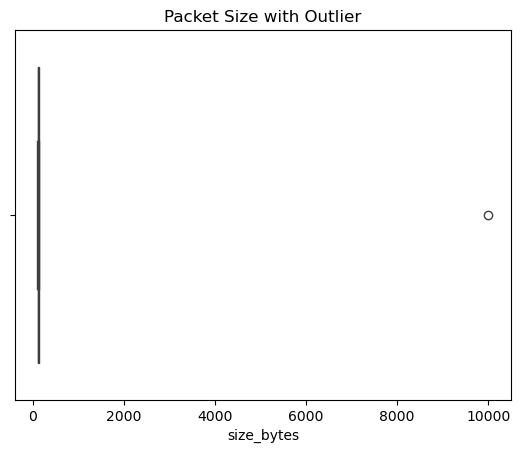

In [9]:
# Initialize Exercise 2 Data
packet_data = {
    'packet_id': range(1, 21),
    'size_bytes': [
        100, 120, 110, 130, 105, 115, 125, 140, 108, 118,
        135, 122, 112, 128, 102, 117, 132, 10000, 120, 119
    ]
}
packet_df = pd.DataFrame(packet_data)

# Show the outlier first
sns.boxplot(x=packet_df['size_bytes'])
plt.title("Packet Size with Outlier")
plt.show()

IQR: 17.0
Upper Bound: 154.0
Capping Value (95th %): 633.000000000007


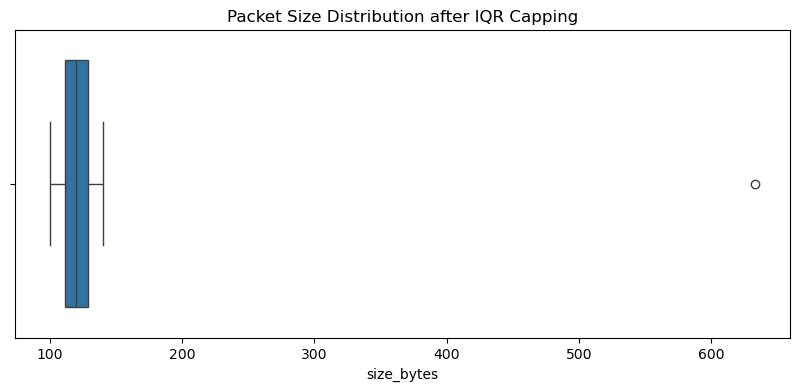

In [10]:
# 1. Calculate IQR
Q1 = packet_df['size_bytes'].quantile(0.25)
Q3 = packet_df['size_bytes'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identify and Cap at the 95th Percentile
# We calculate the 95th percentile of the *original* data to use as our cap
percentile_95 = packet_df['size_bytes'].quantile(0.95)

# Apply the cap to anything above the upper bound
packet_df['size_bytes'] = np.where(packet_df['size_bytes'] > upper_bound, percentile_95, packet_df['size_bytes'])

# 4. Verify the results
print(f"IQR: {IQR}")
print(f"Upper Bound: {upper_bound}")
print(f"Capping Value (95th %): {percentile_95}")

# Plot again to confirm the box looks normal now
plt.figure(figsize=(10, 4))
sns.boxplot(x=packet_df['size_bytes'])
plt.title('Packet Size Distribution after IQR Capping')
plt.show()

In [11]:
# 1. Initialize the Log Data
log_snippet = {
    'log_time': ['2023-10-27 08:00:00', '2023-10-27 08:01:00', '2023-10-27 08:02:00'],
    'event_type': ['LOGIN', 'LOGOUT', 'ACCESS'],
    'user_id': ['user1', 'user2', 'user1'],
    'attempts': ['1', '1', '5']
}
log_df = pd.DataFrame(log_snippet)

# 2. Perform Data Type Conversion
log_df['log_time'] = pd.to_datetime(log_df['log_time'])
log_df['attempts'] = log_df['attempts'].astype(int)

# 3. Verify the changes
print("Cleaned Log Snippet DataFrame:")
print(log_df)
print("\nData types after conversion:")
print(log_df.dtypes)

Cleaned Log Snippet DataFrame:
             log_time event_type user_id  attempts
0 2023-10-27 08:00:00      LOGIN   user1         1
1 2023-10-27 08:01:00     LOGOUT   user2         1
2 2023-10-27 08:02:00     ACCESS   user1         5

Data types after conversion:
log_time      datetime64[ns]
event_type            object
user_id               object
attempts               int64
dtype: object
